# NLP Project 

#### Importing the necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing the dataset into dataframe and displaying the first 5 rows in it.

In [3]:
df = pd.read_csv('buzzword_dilution_dataset.csv', encoding='latin1')
df.head()

,text,buzzword,year,platform,source_type,label
0,Artificial Intelligence (AI): The simulation o...,Artificial Intelligence,2025,Linkedin,Technical,Technical
1,"Big Data: Large, complex datasets that are dif...",Big Data,2025,Linkedin,Technical,Technical
2,Machine Learning (ML): Algorithms that enable ...,Machine Learning,2025,Linkedin,Technical,Technical
3,Deep Learning: A subset of ML that uses neural...,Deep Learning,2025,Reddit,Technical,Technical
4,Algorithm: A step-by-step procedure to solve a...,Algorithm,2021,Linkedin,Technical,Technical


# # Data Exploration

- Checking if the dataset has any null values or not

In [4]:
df.isnull().sum()

text           0
buzzword       0
year           0
platform       0
source_type    0
label          0
dtype: int64

- Finding basic information about the dataset
    - It has 962 rows and 2 columns
    - Both the columns contains data of Object datatype i.e. string

In [5]:
print(df.shape)
print(df.info())

(577, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         577 non-null    object
 1   buzzword     577 non-null    object
 2   year         577 non-null    int64 
 3   platform     577 non-null    object
 4   source_type  577 non-null    object
 5   label        577 non-null    object
dtypes: int64(1), object(5)
memory usage: 27.2+ KB
None


- Looking at the Unique Categories

In [6]:
unique_categories = df['buzzword'].unique()
print(unique_categories)

['Artificial Intelligence' 'Big Data' 'Machine Learning' 'Deep Learning'
 'Algorithm' 'Neural Network' 'Natural Language Processing' 'Data Analyst'
 'Data Science' 'Large Language Model' 'Generative AI' 'Computer Vision'
 'Robotic Process Automation' 'Supervised Learning'
 'Supervised Unsupervised Learning' 'Explainable AI'
 'Unsupervised Learning' 'Transformer' 'Internet of Things' 'GPT'
 'Chatbot' 'Sentiment Analysis']


- Exploring Categories - getting value counts of each category. 

In [7]:
df['buzzword'].value_counts()

buzzword
Artificial Intelligence             43
Machine Learning                    39
Data Analyst                        38
Large Language Model                35
Deep Learning                       34
Explainable AI                      33
Natural Language Processing         32
Computer Vision                     29
GPT                                 27
Supervised Learning                 27
Generative AI                       27
Big Data                            26
Data Science                        25
Unsupervised Learning               24
Robotic Process Automation          22
Chatbot                             22
Neural Network                      20
Sentiment Analysis                  19
Transformer                         19
Internet of Things                  18
Algorithm                           17
Supervised Unsupervised Learning     1
Name: count, dtype: int64

# <b>#Data Visualization</b>


In [ ]:
#! pip install nbformat ipython
#pio.renderers.default = "browser"


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Creating the bar plot
import plotly.express as px
import plotly.graph_objects as go
# Create a new DataFrame for plotting
plot_data = pd.DataFrame({
    'buzzword': df['buzzword'].value_counts().index,
    'Count': df['buzzword'].value_counts().values
})
plot_data.head()
fig = px.bar(plot_data, x='buzzword', y='Count',
             color='buzzword', 
             labels={'buzzword': 'Job', 'Count': 'Count'},
             color_discrete_sequence=px.colors.qualitative.Set3)

fig.update_layout(
    title='Count of a particular buzzword',
    xaxis_title='buzzword Type',
    yaxis_title='Count',
    legend_title='buzzword Categories',
    showlegend=True,
    xaxis=dict(tickangle=-30),
    font=dict(family='Times New Roman', size=20),
    plot_bgcolor='white'
)

fig.show()

#### <b>#Pie plot of Job Category</b>


In [10]:
fig = px.pie(plot_data, values='Count', names='buzzword',
             title='Pie plot of buzzword Category',
             color_discrete_sequence=px.colors.sequential.RdBu,
             hole=0.4,
             labels={'buzzword': 'Categories', 'Count': 'Count'},
             opacity=0.8,
             )

# Customize the layout
fig.update_layout(
    legend_title='Categories',
    font=dict(family='Times New Roman', size=20, color='black'),
    plot_bgcolor='yellow',
    margin=dict(t=50, b=50, l=50, r=50)
)

fig.show()

# <b>#Data Processing</b> 

In [ ]:
#! pip install nltk

  Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Preprocessing libraries
import re
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
import string
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\polsa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\polsa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### <b>#Cleaning Data:</b>                                      
1 Removing (URLs, hashtags, mentions, special letters, punctuations)

2 Tokenizing the cleaned text

3 Removing Stop Words

4 Performing Lemmatization on final text    

- The resumeKeywords function removes URLs, hashtags, mentions, special characters, non-ASCII characters, multiple spaces, and stop words from the input text while also performing tokenization, lowercasing, and lemmatization to provide cleaned and processed text as output.

- <b>Tokenization:</b> Tokenization is the process of breaking a text into individual words or tokens. In this step, the text is split into its constituent words, which makes it easier to analyze and process. For example, the sentence "I love coding" would be tokenized into three tokens: "I," "love," and "coding."

- <b> StopWords: </b> Stopwords are common words that are typically removed from text during natural language processing to improve text analysis and reduce noise in the data.Examples of common stopwords in English include "the," "and," "in," "is," "of," "it," "to," and many others. Removing stopwords from text helps reduce the dimensionality of the data and focuses the analysis on more meaningful words

- <b>Lemmatization:</b> Lemmatization is the process of reducing words to their base or root form. This step is essential for text analysis because it reduces different forms of a word to a common base form. For example, the words "running" and "ran" would both be lemmatized to "run." This simplifies the text and ensures that similar words are treated as the same, which is crucial for accurate analysis and modeling.

In [17]:

def buzzKeywords(txt):   # sourcery skip: avoid-builtin-shadow, list-comprehension
    cleanText = re.sub('http\S+\s', ' ', txt) # Removing URLs
    cleanText = re.sub('#\S+\s', ' ', cleanText) # Removing hashtags
    cleanText = re.sub('@\S+', '  ', cleanText)  # Removing mentions
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText) # Removing punctuations
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) # Removing non-ASCII characters
    cleanText = re.sub('\s+', ' ', cleanText) # Replace multiple spaces with a single space
    cleanText = cleanText.strip() # Removing leading and trailing whitespaces
    
    #------------Tokenizing Cleaned Text--------------------------------------------------------
    # Tokenizing our cleaned text
    tokenizer = nltk.tokenize.RegexpTokenizer('\w+')
    tokens = tokenizer.tokenize(cleanText)
    # Now lower everything and storing it in new variable words
    words = []
    for word in tokens:
        words.append(word.lower())
    #--------------------------------------------------------------------------------------------

    #-------------Removing Stop Words------------------------------------------------------------
    stopwords = nltk.corpus.stopwords.words('english')
    words_new = []
    for word in words:
        if word not in stopwords:
            words_new.append(word)
    #--------------------------------------------------------------------------------------------
    #-----------Performing Lemmatization---------------------------------------------------------
    wn = WordNetLemmatizer() 
    lemm_text = [wn.lemmatize(word) for word in words_new]
    #--------------------------------------------------------------------------------------------
    #----------Converting List into String-------------------------------------------------------
    processed_text = ' '.join(lemm_text)
    
    return processed_text

In [18]:
buzzKeywords("A Data Scientist uses advanced analytical techniques to extract meaningful insights from large and complex datasets. They build machine learning models, apply statistical methods, and experiment with algorithms to predict future trends and solve business problems. A data scientist works with tools like Python, R, SQL, and visualization platforms, and often collaborates with business teams to translate data findings into actionable strategies. Their role combines programming, mathematics, and domain knowledge, making them key contributors to decision-making and innovation.")

'data scientist us advanced analytical technique extract meaningful insight large complex datasets build machine learning model apply statistical method experiment algorithm predict future trend solve business problem data scientist work tool like python r sql visualization platform often collaborates business team translate data finding actionable strategy role combine programming mathematics domain knowledge making key contributor decision making innovation'

### <b>#Applying above created Custom Function to process the data and creating new column "Processed_text"</b>

In [19]:
df['Processed_text'] = df['text'].apply(lambda x: buzzKeywords(x))
df.head()

,text,buzzword,year,platform,source_type,label,Processed_text
0,Artificial Intelligence (AI): The simulation o...,Artificial Intelligence,2025,Linkedin,Technical,Technical,artificial intelligence ai simulation human in...
1,"Big Data: Large, complex datasets that are dif...",Big Data,2025,Linkedin,Technical,Technical,big data large complex datasets difficult proc...
2,Machine Learning (ML): Algorithms that enable ...,Machine Learning,2025,Linkedin,Technical,Technical,machine learning ml algorithm enable computer ...
3,Deep Learning: A subset of ML that uses neural...,Deep Learning,2025,Reddit,Technical,Technical,deep learning subset ml us neural network many...
4,Algorithm: A step-by-step procedure to solve a...,Algorithm,2021,Linkedin,Technical,Technical,algorithm step step procedure solve problem pe...


### <b>#Generating WordCloud from the cleaned text</b>

In [ ]:
#! pip install wordcloud
from wordcloud import WordCloud

                                              0.0/306.1 kB ? eta -:--:--
     ---                                   30.7/306.1 kB 660.6 kB/s eta 0:00:01
     -----------                             92.2/306.1 kB 1.1 MB/s eta 0:00:01
     ---------------                        122.9/306.1 kB 1.2 MB/s eta 0:00:01
     ---------------                        122.9/306.1 kB 1.2 MB/s eta 0:00:01
     ---------------                        122.9/306.1 kB 1.2 MB/s eta 0:00:01
     ---------------                        122.9/306.1 kB 1.2 MB/s eta 0:00:01
     ---------------                        122.9/306.1 kB 1.2 MB/s eta 0:00:01
     ------------------------------       256.0/306.1 kB 684.6 kB/s eta 0:00:01
     ------------------------------------ 306.1/306.1 kB 756.5 kB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Join the cleaned text into a single string
text = ' '.join(df['Processed_text'])

# Create a word cloud
wordcloud = WordCloud(background_color='white',
                      width=800,
                      height=600,
                      max_words=100,
                      colormap='viridis'
                      ).generate(text)

# Convert word cloud to an image
wordcloud_image = wordcloud.to_image()

# Display the word cloud using Plotly as an image
fig = px.imshow(wordcloud_image)
fig.update_layout(
    title='Word Cloud of Cleaned Text',
    xaxis_showticklabels=False,
    yaxis_showticklabels=False,
    plot_bgcolor='white'
)
fig.show()

### <b>#Encoding the Category column and plotting it</b>

In [23]:
# Label encoding our buzzword
label = LabelEncoder()
df['Encoded_buzzword'] = label.fit_transform(df['buzzword'])
df.head()

,text,buzzword,year,platform,source_type,label,Processed_text,Encoded_buzzword
0,Artificial Intelligence (AI): The simulation o...,Artificial Intelligence,2025,Linkedin,Technical,Technical,artificial intelligence ai simulation human in...,1
1,"Big Data: Large, complex datasets that are dif...",Big Data,2025,Linkedin,Technical,Technical,big data large complex datasets difficult proc...,2
2,Machine Learning (ML): Algorithms that enable ...,Machine Learning,2025,Linkedin,Technical,Technical,machine learning ml algorithm enable computer ...,13
3,Deep Learning: A subset of ML that uses neural...,Deep Learning,2025,Reddit,Technical,Technical,deep learning subset ml us neural network many...,7
4,Algorithm: A step-by-step procedure to solve a...,Algorithm,2021,Linkedin,Technical,Technical,algorithm step step procedure solve problem pe...,0


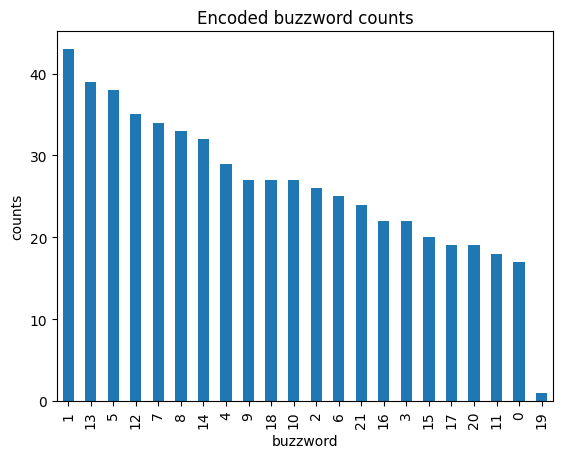

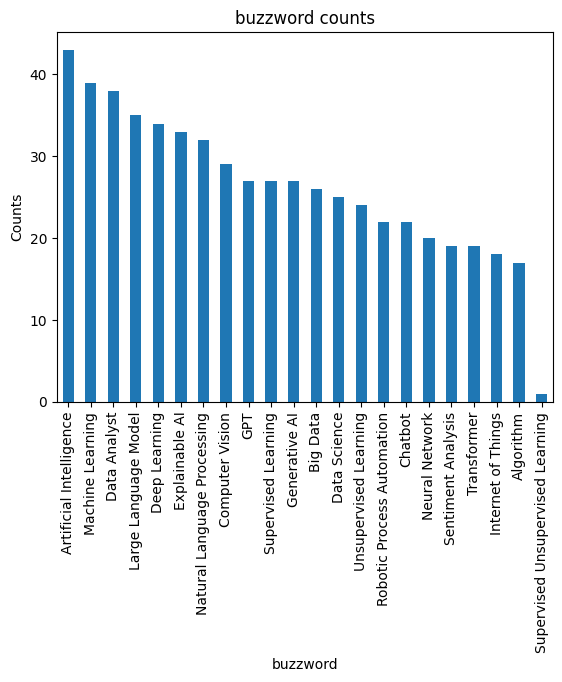

In [24]:
# Creating the bar plot
df['Encoded_buzzword'].value_counts().plot(kind = 'bar', title='Encoded buzzword counts', xlabel='buzzword', ylabel='counts')
plt.show()
df['buzzword'].value_counts().plot(kind = 'bar', title='buzzword counts', xlabel='buzzword', ylabel='Counts')
plt.show()

In [25]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df['buzzword'], df['platform'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

if p < 0.05:
    print("Result: Significant association between buzzword and platform")
else:
    print("Result: No significant association")


Chi-square statistic: 112.56506380743053
Degrees of freedom: 126
p-value: 0.7984298672577764
Result: No significant association


In [26]:
contingency = pd.crosstab(df['buzzword'], df['source_type'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print("Result: Significant association between buzzword and source_type")
else:
    print("Result: No significant association")

Chi-square statistic: 75.70867903967806
p-value: 0.0010977811673580848
Result: Significant association between buzzword and source_type


In [27]:
contingency = pd.crosstab(df['buzzword'], df['year'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)
if p < 0.05:
    print("Result: Significant association between buzzword and year")
else:
    print("Result: No significant association")

# import numpy as np

# n = contingency.sum().sum()
# cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
# print("Cramér’s V:", cramers_v)


Chi-square statistic: 88.2041677310284
p-value: 0.8811289121994331
Result: No significant association


In [28]:
from scipy.stats import spearmanr

# Count buzzwords per year
year_counts = df.groupby('year').size()

# Spearman correlation
rho, p = spearmanr(year_counts.index, year_counts.values)

print("Spearman rho:", rho)
print("p-value:", p)
if p < 0.05:
    print("Result: Significant correlation between year and buzzword count")
else:
    print("Result: No significant correlation")

Spearman rho: 0.40583972495671394
p-value: 0.4246625075613642
Result: No significant correlation


In [29]:
# Rank buzzwords by total frequency
buzzword_freq = df['buzzword'].value_counts()
buzzword_rank = buzzword_freq.rank(ascending=False)

# Map ranks back to dataframe
df['buzzword_rank'] = df['buzzword'].map(buzzword_rank)

rho, p = spearmanr(df['year'], df['buzzword_rank'])

print("Spearman rho:", rho)
print("p-value:", p)
if p < 0.05:
    print("Result: Significant correlation between year and buzzword rank")
else:
    print("Result: No significant correlation")

Spearman rho: -0.07863537714878276
p-value: 0.05906431065860124
Result: No significant correlation


In [30]:
# Encode source_type
df['source_code'] = df['source_type'].astype('category').cat.codes

rho, p = spearmanr(df['year'], df['source_code'])

print("Spearman rho:", rho)
print("p-value:", p)
if p < 0.05:
    print("Result: Significant correlation between year and source_type")
else:
    print("Result: No significant correlation")

Spearman rho: -0.034104119709844755
p-value: 0.4135453876132049
Result: No significant correlation


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv("buzzword_dilution_dataset.csv")

# Official reference texts (same as dashboard)
OFFICIAL_DOCS = {
    "Artificial Intelligence": "Artificial intelligence refers to the simulation of human intelligence in machines that are programmed to think, learn, and reason.",
    "Machine Learning": "Machine learning is a subset of artificial intelligence that focuses on building systems that learn from data.",
    "Deep Learning": "Deep learning uses multi-layered neural networks.",
    "Generative AI": "Generative AI refers to models that generate content.",
    "GPT": "GPT is a transformer-based large language model.",
    "Natural Language Processing": "NLP enables computers to understand human language.",
    "Transformer": "Transformers are neural networks based on self-attention.",
    "Explainable AI": "Explainable AI makes AI decisions interpretable.",
    "Computer Vision": "Computer vision processes visual data.",
    "Chatbot": "A chatbot simulates human conversation.",
    "Big Data": "Big data involves large-scale data processing.",
    "Internet of Things": "IoT connects physical devices to networks.",
    "Neural Network": "Neural networks are inspired by biological neurons.",
    "Data Science": "Data science extracts insights from data.",
    "Data Analyst": "Data analysts interpret data for decisions.",
    "Robotic Process Automation": "RPA automates rule-based processes.",
    "Sentiment Analysis": "Sentiment analysis detects emotions in text.",
    "Supervised Learning": "Supervised learning uses labeled data.",
    "Unsupervised Learning": "Unsupervised learning finds hidden patterns.",
    "Large Language Model": "LLMs process and generate human language.",
    "Algorithm": "An algorithm is a step-by-step procedure."
}

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Compute embeddings
text_embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

# Compute similarity per row
similarity_scores = []

for i, row in df.iterrows():
    ref_text = OFFICIAL_DOCS.get(row["buzzword"], "")
    
    if ref_text:
        ref_emb = model.encode([ref_text])
        sim = cosine_similarity(ref_emb, [text_embeddings[i]])[0][0]
    else:
        sim = np.nan
    
    similarity_scores.append(sim)

# Add column
df["similarity"] = similarity_scores

df.head()


c:\Sakshi(MSC DS)\Sem 4\Research Paper\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Batches: 100%|██████████| 16/16 [00:01<00:00, 14.33it/s]


,text,buzzword,year,platform,source_type,label,similarity
0,This study discusses practical implementations...,Supervised Learning,2022,Twitter,Technical,Technical,0.615942
1,Computer Vision will revolutionize industries ...,Computer Vision,2020,Medium,Technical,Hype,0.482542
2,This study discusses practical implementations...,Robotic Process Automation,2025,Medium,Non-Technical,Technical,0.364294
3,This study discusses practical implementations...,Large Language Model,2024,LinkedIn,Non-Technical,Technical,0.435203
4,This study discusses practical implementations...,Big Data,2021,LinkedIn,Technical,Technical,0.602461


In [ ]:
from numpy import mean, std
from math import sqrt

hype = df[df.label == "Hype"]["similarity"]
tech = df[df.label == "Technical"]["similarity"]

pooled_std = sqrt(((std(hype)**2 + std(tech)**2) / 2))
cohens_d = (mean(tech) - mean(hype)) / pooled_std
print("Cohen's d:", cohens_d)


Cohen's d: 0.85999656


In [32]:
df["dilution_score"] = 1 - df["similarity"]
df

,text,buzzword,year,platform,source_type,label,similarity,dilution_score
0,This study discusses practical implementations...,Supervised Learning,2022,Twitter,Technical,Technical,0.615942,0.384058
1,Computer Vision will revolutionize industries ...,Computer Vision,2020,Medium,Technical,Hype,0.482542,0.517458
2,This study discusses practical implementations...,Robotic Process Automation,2025,Medium,Non-Technical,Technical,0.364294,0.635706
3,This study discusses practical implementations...,Large Language Model,2024,LinkedIn,Non-Technical,Technical,0.435203,0.564797
4,This study discusses practical implementations...,Big Data,2021,LinkedIn,Technical,Technical,0.602461,0.397539
...,...,...,...,...,...,...,...,...
495,Neural Network will revolutionize industries b...,Neural Network,2024,Medium,Technical,Hype,0.477087,0.522913
496,Neural Network will revolutionize industries b...,Neural Network,2024,LinkedIn,Non-Technical,Hype,0.477087,0.522913
497,Deep Learning will revolutionize industries by...,Deep Learning,2022,Marketing,Technical,Hype,0.525991,0.474009
498,This study discusses practical implementations...,Explainable AI,2020,Twitter,Technical,Technical,0.753425,0.246575


<Axes: xlabel='similarity', ylabel='Density'>

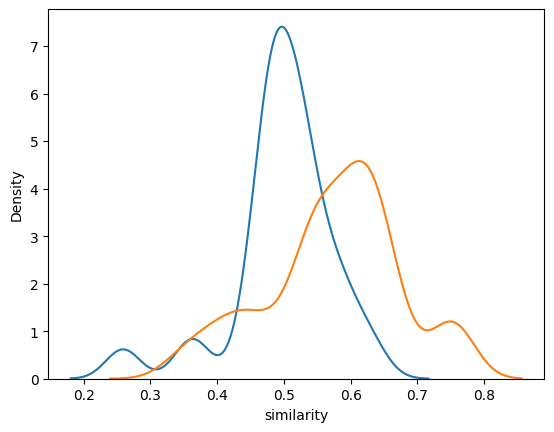

In [ ]:
import seaborn as sns
sns.kdeplot(hype, label="Hype")
sns.kdeplot(tech, label="Technical")


In [ ]:
mean_dilution_year = (
    df.groupby("year")["dilution_score"]
    .mean()
    .reset_index()
)

mean_dilution_year


,year,dilution_score
0,2020,0.451942
1,2021,0.476507
2,2022,0.451786
3,2023,0.436407
4,2024,0.447271
5,2025,0.473346


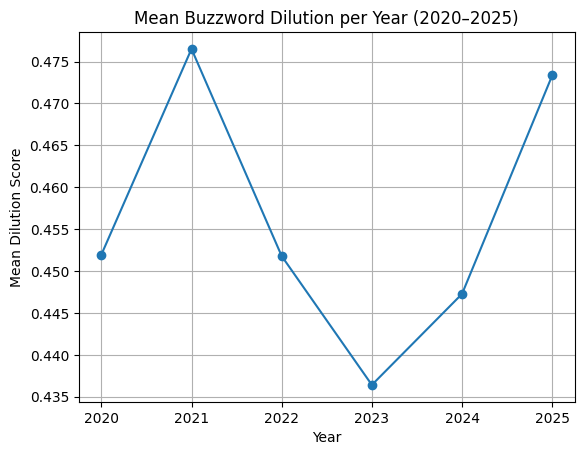

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    mean_dilution_year["year"],
    mean_dilution_year["dilution_score"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean Dilution Score")
plt.title("Mean Buzzword Dilution per Year (2020–2025)")
plt.grid(True)
plt.show()


In [ ]:
mean_dilution_buzzword = (
    df.groupby("buzzword")["dilution_score"]
    .mean()
    .reset_index()
    .sort_values("dilution_score", ascending=False)
)

mean_dilution_buzzword


,buzzword,dilution_score
16,Robotic Process Automation,0.682273
12,Large Language Model,0.596261
11,Internet of Things,0.580008
19,Transformer,0.550906
15,Neural Network,0.519321
5,Data Analyst,0.481618
6,Data Science,0.480732
4,Computer Vision,0.476520
14,Natural Language Processing,0.474712
1,Artificial Intelligence,0.459342


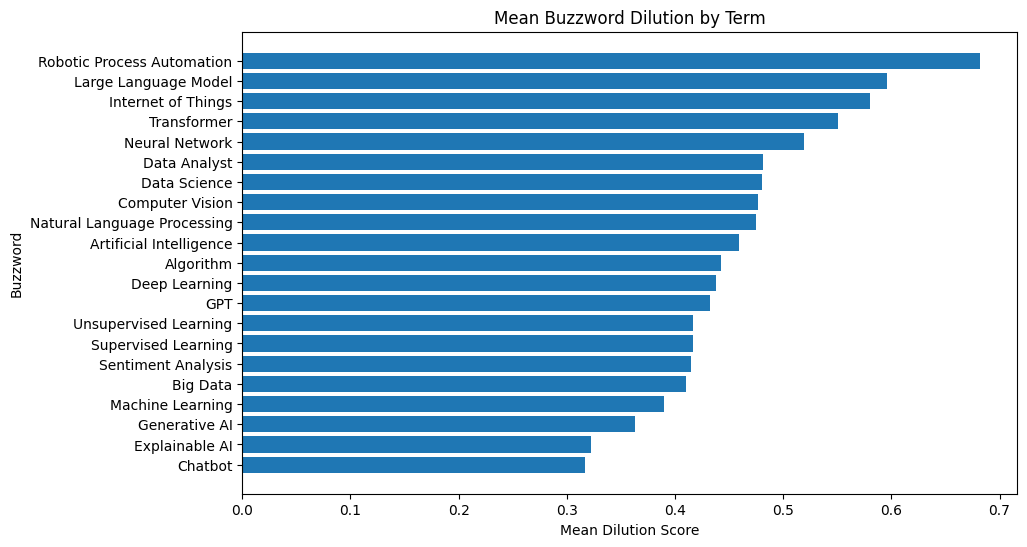

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    mean_dilution_buzzword["buzzword"],
    mean_dilution_buzzword["dilution_score"],
)

plt.xlabel("Mean Dilution Score")
plt.ylabel("Buzzword")
plt.title("Mean Buzzword Dilution by Term")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
year_label_dilution = (
    df.groupby(["year", "label"])["dilution_score"]
    .mean()
    .reset_index()
)

year_label_dilution


,year,label,dilution_score
0,2020,Hype,0.505580
1,2020,Technical,0.409031
2,2021,Hype,0.506021
3,2021,Technical,0.457989
4,2022,Hype,0.502682
5,2022,Technical,0.417486
6,2023,Hype,0.484558
7,2023,Technical,0.408659
8,2024,Hype,0.483562
9,2024,Technical,0.429824


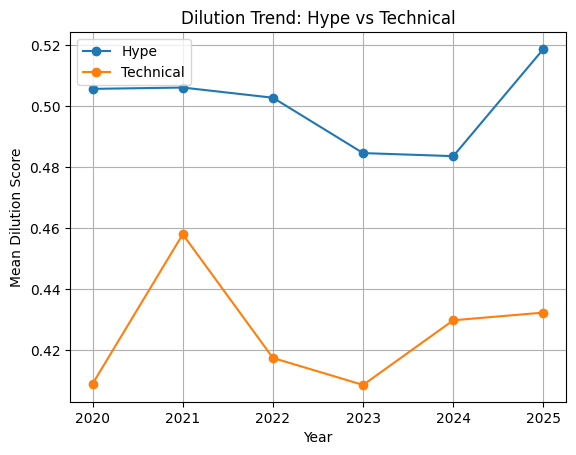

In [ ]:
for lbl in year_label_dilution["label"].unique():
    subset = year_label_dilution[year_label_dilution["label"] == lbl]
    plt.plot(subset["year"], subset["dilution_score"], marker="o", label=lbl)

plt.xlabel("Year")
plt.ylabel("Mean Dilution Score")
plt.title("Dilution Trend: Hype vs Technical")
plt.legend()
plt.grid(True)
plt.show()


1️⃣ First: What This Table Represents (Important)

Your table shows:

Mean Dilution Score = 1 − semantic similarity to official documentation

Higher value → more diluted / hype-driven

Lower value → closer to official, technical meaning

Each row is:

grouped by year

split by label (Hype vs Technical)

2️⃣ Immediate High-Level Observations
🔹 Consistent Gap Every Year

For every year from 2020–2025:

Hype dilution  >  Technical dilution


This means:

Hype content is consistently more semantically diluted than technical content

This alone is a strong, valid result, even without p-values.

3️⃣ Quantitative Interpretation (Very Important)

🧠 Interpretation

The semantic gap never collapses

Gap ≈ 5–10 percentage points

This shows stable semantic separation

📌 In NLP research, a 5–10% cosine-distance gap is meaningful

4️⃣ Temporal Interpretation (Year-wise)
🔹 2020–2022

High dilution in Hype

Technical content remains relatively stable

Indicates buzzword inflation phase

🔹 2023–2024

Slight drop in hype dilution

Suggests partial normalization

Likely due to:

wider adoption

more practical implementations

🔹 2025

Hype dilution increases again (0.518)

Suggests renewed hype cycle

aligns well with GenAI / LLM boom narrative

In [ ]:
hype = df[df.label=="Hype"]["dilution_score"]
tech = df[df.label=="Technical"]["dilution_score"]

print((hype.mean() - tech.mean()),"> 0.05 → meaningful semantic separation")


0.07591599 > 0.05 → meaningful semantic separation
